In [9]:
import json
import pandas as pd

In [8]:
DATA_FOLDER = "../data"
INTERACTION_FILE = "Beauty_and_Personal_Care.jsonl"

PARENT_ASIN_MAPPING_FILE = "item_map.json"

In [10]:
item_mapping = json.load(open(f"{DATA_FOLDER}/{PARENT_ASIN_MAPPING_FILE}", "r", encoding="utf-8"))
print(f"Loaded {len(item_mapping)} items from {DATA_FOLDER}/{PARENT_ASIN_MAPPING_FILE}")

Loaded 595753 items from ../data/item_map.json


In [7]:
# Starting counter value (due to enumerate on the original file)
COUNTER = max(item_mapping.values()) + 1

Atomic files are basically tsv files.

## Raw Text Data (Title Only)

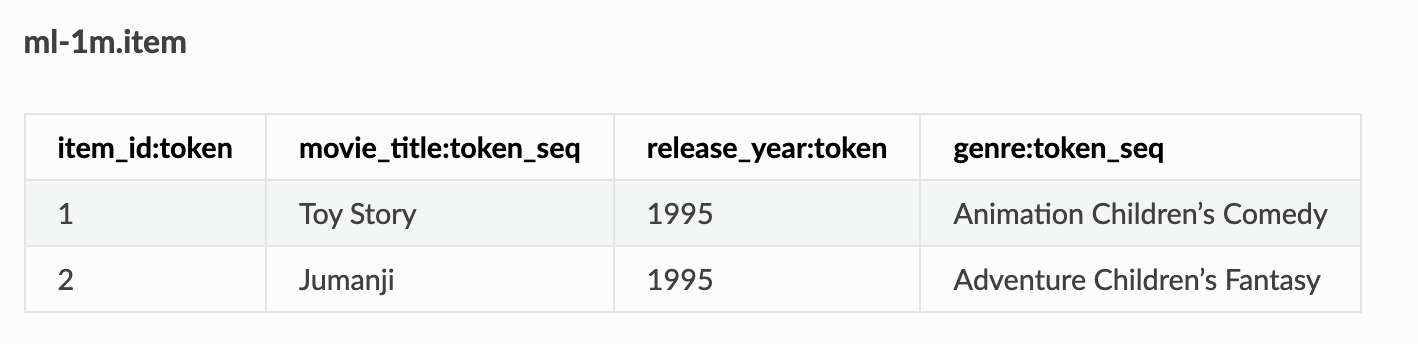

In [ ]:
ITEM_ATOMIC_FILE = "Beauty_and_Personal_Care/Beauty_and_Personal_Care_raw_title.item"
RAW_ITEM_FILE = "meta_Beauty_and_Personal_Care.jsonl"

CHUNK_SIZE = 100_000

with open(f"{DATA_FOLDER}/{ITEM_ATOMIC_FILE}", "w", encoding="utf-8") as output_file:
    # Header
    output_file.write(
        "item_id:token\t"
        "title:token_seq\n"
    )
    
    reader = pd.read_json(f"{DATA_FOLDER}/{RAW_ITEM_FILE}", lines=True, chunksize=CHUNK_SIZE)
    
    for chunk in reader:
        for _, row in chunk.iterrows():
            parent_asin = row["parent_asin"]
            title = row["title"]
            
            if parent_asin not in item_mapping:
                item_mapping[parent_asin] = COUNTER
                COUNTER += 1
            
            item_id = item_mapping[parent_asin]
            
            output_file.write(f"{item_id}\t{title}\n")

## Raw Text Data (Title + Description)

In [13]:
ITEM_ATOMIC_FILE = "Beauty_and_Personal_Care/Beauty_and_Personal_Care_raw_title_desc.item"
RAW_ITEM_FILE = "meta_Beauty_and_Personal_Care.jsonl"

CHUNK_SIZE = 100_000

with open(f"{DATA_FOLDER}/{ITEM_ATOMIC_FILE}", "w", encoding="utf-8") as output_file:
    # Header
    output_file.write(
        "item_id:token\t"
        "title:token_seq\t"
        "description:token_seq\n"
    )
    
    reader = pd.read_json(f"{DATA_FOLDER}/{RAW_ITEM_FILE}", lines=True, chunksize=CHUNK_SIZE)
    
    for chunk in reader:
        for _, row in chunk.iterrows():
            parent_asin = row["parent_asin"]
            title = row["title"]
            description = " ".join(row["description"]) # description is a list
            
            if parent_asin not in item_mapping:
                item_mapping[parent_asin] = COUNTER
                COUNTER += 1
            
            item_id = item_mapping[parent_asin]
            
            output_file.write(f"{item_id}\t{title}\t{description}\n")

## Raw Text Data (Title + Features)

In [14]:
ITEM_ATOMIC_FILE = "Beauty_and_Personal_Care/Beauty_and_Personal_Care_raw_title_features.item"
RAW_ITEM_FILE = "meta_Beauty_and_Personal_Care.jsonl"

CHUNK_SIZE = 100_000

with open(f"{DATA_FOLDER}/{ITEM_ATOMIC_FILE}", "w", encoding="utf-8") as output_file:
    # Header
    output_file.write(
        "item_id:token\t"
        "title:token_seq\t"
        "features:token_seq\n"
    )
    
    reader = pd.read_json(f"{DATA_FOLDER}/{RAW_ITEM_FILE}", lines=True, chunksize=CHUNK_SIZE)
    
    for chunk in reader:
        for _, row in chunk.iterrows():
            parent_asin = row["parent_asin"]
            title = row["title"]
            features = " ".join(row["features"]) # features is a list
            
            if parent_asin not in item_mapping:
                item_mapping[parent_asin] = COUNTER
                COUNTER += 1
            
            item_id = item_mapping[parent_asin]
            
            output_file.write(f"{item_id}\t{title}\t{features}\n")

## Text Embeddings (WIP)

In [ ]:
CHUNK_SIZE = 100_000
ITEM_ATOMIC_FILE = "Beauty_and_Personal_Care_text_embeddings.item"
EMBEDDING_FILE = "emb_Beauty_and_Personal_Care.jsonl"

emb_reader = pd.read_json(f"{DATA_FOLDER}/{EMBEDDING_FILE}", lines=True, chunksize=CHUNK_SIZE)

with open(f"{DATA_FOLDER}/{ITEM_ATOMIC_FILE}", "w", encoding="utf-8") as item_atomic_file:
    # Header first
    item_atomic_file.write(
        "item_id:token\t"
        "title:token\n"
    )
    
    for chunk in emb_reader:
        for row in chunk.itertuples(index=False):
            if row.parent_asin not in item_mapping:
                item_mapping[row.parent_asin] = counter
                counter += 1
        
                

/var/folders/2v/617m0pq96qq942zr8nbfyzch0000gn/T/ipykernel_63023/2930682955.py:6: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  emb_reader = pd.read_json(f"{DATA_FOLDER}/{EMBEDDING_FILE}", lines=True, chunksize=CHUNK_SIZE)


ValueError: Expected object or value